In [921]:
import os
import pandas as pd
import math
import matplotlib.pyplot as plt
import numpy as np
import seaborn
import time

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

In [922]:
STUDENT_ID = 42

In [923]:
df = pd.read_csv('glass.data', names=["Id", "RI","Na","Mg","Al","Si","K","Ca","Ba","Fe", "Class Type"])
target_names = ['building_windows_float_processed', "building_windows_non_float_processed", "vehicle_windows_float_processed", "vehicle_windows_non_float_processed", "containers", "tableware", "headlamps"]

Retrieve the dataset from the "glass.data" textfile.
Retrieve the category names for the dataset.

```df``` = Entire "glass" Dataset.

```target_names``` = All Categories of "glass" dataset.

In [924]:
X = df.drop(columns=["Id", "Class Type"])
y = df["Class Type"]

Define ```X``` and ```y``` as the data and corresponding category/class_type respectively.

In [925]:
# Split Data
x_temp, x_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=STUDENT_ID, stratify=y)
x_train, x_validate, y_train, y_validate = train_test_split(x_temp, y_temp, test_size=0.25, random_state=STUDENT_ID, stratify=y_temp)  

Split the data into three sections.

```x_test``` ```y_test``` : Used to test the model.

```x_train``` ```y_train``` : Used to train the model.

```x_validate``` ```y_validate``` : Used to fine-tune the model.

In [926]:
# # Feature Scaling via standardisation
# x_mean = x_train.mean()
# x_std = x_train.std() + 0.000000001

# x_train_scaled = (x_train - x_mean) / x_std
# x_test_scaled = (x_test - x_mean) / x_std
# x_validate_scaled = (x_validate - x_mean) / x_std

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_validate_scaled = scaler.transform(x_validate)
x_test_scaled = scaler.transform(x_test)

Feature scaling implemented via standardisation / z-score normalisation.

Uses the ```x_train``` dataframe to get a mean and standard diviation, replaces 0 with 1 in ```x_std``` and then standardises ```x_train```,```x_test```, and ```x_validate```

In [927]:
class knn_classifier:
    k = 1
    x_train_data = None
    y_train_data = None
    distance_list = []

    def __init__(self, init_k = -1):
        if (init_k >= 1):
            self.k = init_k
            return
    
    def fit(self, x, y):
        self.x_train_data = x
        self.y_train_data = y

    def euclidean_squared_distance(self, test_row):
        self.distance_list = []
        for i in range (len(self.x_train_data)):
            distance = 0.0
            
            train_row = self.x_train_data[i]

            for y in range(len(train_row)):
                distance += (test_row[y] - train_row[y]) ** 2

            self.distance_list.append((i, distance))
        self.distance_list.sort(key=lambda x: x[1])

    def manhattan_distance(self, test_row):
        self.distance_list = []
        for i in range (len(self.x_train_data)):
            distance = 0.0
            
            train_row = self.x_train_data[i]

            for y in range(len(train_row)):
                distance += abs((test_row[y] - train_row[y]))

            self.distance_list.append((i, math.sqrt(distance)))
        self.distance_list.sort(key=lambda x: x[1])

    def maximum_distance(self, test_row):
        self.distance_list = []
        for i in range (len(self.x_train_data)):
            distance = 0.0
            
            train_row = self.x_train_data[i]

            for y in range(len(train_row)):
                temp_distance = abs((test_row[y] - train_row[y]))
                if temp_distance > distance:
                    distance = temp_distance


            self.distance_list.append((train_row, math.sqrt(distance)))
        self.distance_list.sort(key=lambda x: x[1])

    
    def get_nearest_neighbors(self):
        neighbors_list = []
        for i in range (self.k):
            row_num = self.distance_list[i][0]
            y = self.y_train_data.iloc[row_num]
            neighbors_list.append(y)
        return neighbors_list

    def predict_classification(self, test_row):
        self.euclidean_squared_distance(test_row)
        neighbors = self.get_nearest_neighbors()
        prediction = max(neighbors, key=neighbors.count)
        return prediction


    def best_k(self, x, y):
        best_accuracy = 0
        best_k_value = None

        for newK in range(1, 11, 2): # Odds only
            self.k = newK
            predictions = []

            for x_item in x:
                prediction = self.predict_classification(x_item)
                predictions.append(prediction)
                npPredictions = np.array(predictions)
            accuracy = np.mean(npPredictions == y.values) * 100
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_k_value = newK
        self.k = best_k_value

In [928]:
knn_model = knn_classifier()
knn_model.fit(x_train_scaled, y_train)
knn_model.best_k(x_validate_scaled, y_validate)

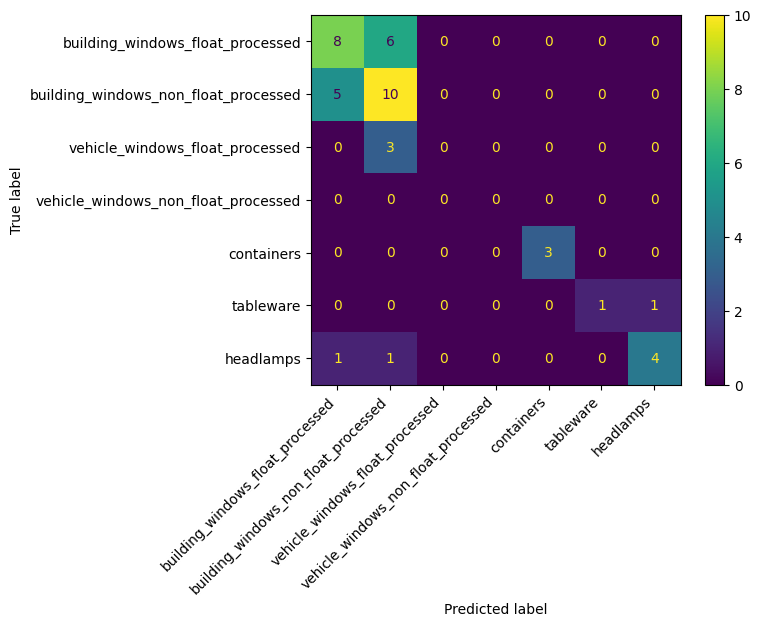

For K 7, Accuracy is 60.46511627906976


In [ ]:
test_predictions = []
test_actual = []

def testKNN():
    for i in range(len(x_test_scaled)):
        prediction = knn_model.predict_classification(x_test_scaled[i])
        test_predictions.append(prediction)
        test_actual.append(y_test.iloc[i])

    cm = confusion_matrix(y_true=test_actual, y_pred=test_predictions, labels=[1,2,3,4,5,6,7])

    cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=target_names)

    cm_display.plot()

    plt.setp(cm_display.ax_.get_xticklabels(), rotation=45, ha="right")
    plt.show() 

    accuracy = np.mean(np.array(test_predictions) == y_test) * 100
    print(f'For K={knn_model.k}, Accuracy is {accuracy}')
testKNN()

In [930]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

# First split: train + validation vs test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=STUDENT_ID
)

# Second split: train vs validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=STUDENT_ID
)  
# 0.25 of 0.8 = 0.2 → final split: 60% train, 20% val, 20% test

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Train KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Validation predictions
y_val_pred = knn.predict(X_val_scaled)

# Validation accuracy
val_acc = accuracy_score(y_val, y_val_pred)
print("Validation Accuracy:", val_acc)

# Validation confusion matrix
val_cm = confusion_matrix(y_val, y_val_pred)
print("Validation Confusion Matrix:\n", val_cm)

# Final test evaluation
y_test_pred = knn.predict(X_test_scaled)

test_acc = accuracy_score(y_test, y_test_pred)
print("Test Accuracy:", test_acc)

test_cm = confusion_matrix(y_test, y_test_pred)
print("Test Confusion Matrix:\n", test_cm)

Validation Accuracy: 0.5348837209302325
Validation Confusion Matrix:
 [[ 9  5  0  0  0  0]
 [ 4 10  0  2  0  0]
 [ 4  0  0  0  0  0]
 [ 0  1  0  0  0  2]
 [ 2  0  0  0  0  0]
 [ 0  0  0  0  0  4]]
Test Accuracy: 0.7906976744186046
Test Confusion Matrix:
 [[14  1  1  0  0  0]
 [ 4 12  0  0  0  0]
 [ 1  0  0  0  0  0]
 [ 0  0  0  1  0  0]
 [ 0  0  0  0  1  1]
 [ 0  1  0  0  0  6]]
